# Notebook: Get Unique Products from VHR Catalog

First, we are combining some `.gpkg` files to gather fields and information that will be useful for the elaboration of the dataset.

This notebook processes Very High Resolution (VHR) satellite data catalogs by:
- Loading product and reference GeoPackage files
- Selecting relevant columns
- Aggregating reference data per datastrip
- Merging datasets
- Analyzing distributions
- Filtering to unique datastrips
- Saving the processed catalog

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

Load the product and reference GeoPackage files into GeoDataFrames.

In [ ]:
PATH_PROD = "VHR2024-REF-PACKAGE-20241122/vhr2024_prod_data.gpkg"
PATH_REF  = "VHR2024-REF-PACKAGE-20241122/vhr2024_data_ref.gpkg"

In [ ]:
g_prod = gpd.read_file(PATH_PROD)
g_ref  = gpd.read_file(PATH_REF)

## Data Preparation

Define the columns to keep from each dataset and check for missing columns.

In [ ]:
# --- Keep only requested fields ---
prod_cols = ["datastrip","geometry","product_id","product_name","provider","mission","ql_url","satellite","mcode"]
ref_cols  = ["datastrip","acq_time","res_m","res_class","elev_angle","ona_angle","cc","haze","prj_det"]

In [ ]:
missing_prod = [c for c in prod_cols if c not in g_prod.columns]
missing_ref  = [c for c in ref_cols  if c not in g_ref.columns]
if missing_prod:
    raise KeyError(f"Missing in prod gpkg: {missing_prod}")
if missing_ref:
    raise KeyError(f"Missing in ref gpkg: {missing_ref}")

In [ ]:
g_prod = g_prod[prod_cols].copy()
g_ref  = g_ref[ref_cols].copy()

## Process Reference Data

Parse acquisition time and aggregate reference data to one row per datastrip.

In [ ]:
# Parse time (important for min/first)
g_ref["acq_time"] = pd.to_datetime(g_ref["acq_time"], utc=True, errors="coerce")

In [ ]:
# Collapse ref to ONE row per datastrip
ref_u = (
    g_ref.groupby("datastrip", as_index=False)
         .agg({
             "acq_time": "min",        # earliest time
             "res_m": "first",
             "res_class": "first",
             "elev_angle": "median",
             "ona_angle": "median",
             "cc": "max",              # worst-case clouds
             "haze": "first",            # worst-case haze
             "prj_det": "first",
         })
)

## Merge Datasets

Merge product and aggregated reference data on datastrip.

In [ ]:
# --- Join ---
g = g_prod.merge(
    ref_u,
    on="datastrip",
    how="left",      # keep all products
    validate="m:1"   
)

In [ ]:
g.keys()

Index(['datastrip', 'geometry', 'product_id', 'product_name', 'provider',
       'mission', 'ql_url', 'satellite', 'mcode', 'acq_time', 'res_m',
       'res_class', 'elev_angle', 'ona_angle', 'cc', 'haze', 'prj_det'],
      dtype='object')

## Data Analysis

Display merged dataframe columns and create visualizations of the data provider distribution.

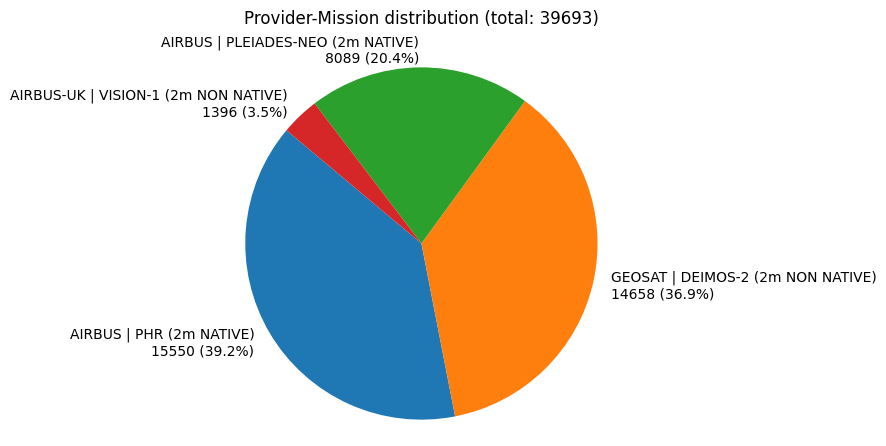

In [ ]:
counts = (
    g.groupby(["provider", "mission", "res_class"])
     .size()
     .sort_values(ascending=False)
)
total = counts.sum()

labels = [
    f"{prov} | {miss} ({res_class})\n{cnt} ({cnt/total*100:.1f}%)"
    for (prov, miss, res_class), cnt in counts.items()
]

plt.figure(figsize=(5, 5))
plt.pie(counts.values, labels=labels, startangle=140)
plt.title(f"Provider-Mission distribution (total: {total})", pad=20)
plt.axis("equal")  # keep circle shape
plt.show()

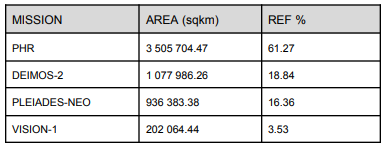

Note: here is a comaprison of the bandwidth of Sentinel-2 MSI and the other providers instruments.

|       | Sentinel-2 | Airbus Pléiades | Airbus Pléiades Neo | Airbus Vision-1 | GeoSAT 2 |
| ----- | ---------- | --------------- | ------------------- | --------------- | --------------- |
| Blue   | 458 - 523 | 430 - 550 | 450-520 | 440-510 | 466 – 525 |    
| Green | 543 - 578 | 500 - 620 | 530 – 590 | 510-590 | 532 – 599 |
| Red  | 650 - 680 | 590 - 710 | 620 – 690 | 600-670 | 640 – 697 |
| NIR   | 785 - 900 | 740 - 940 | 770 – 880 | 760-910 | 770 – 892 |


## Filter Unique Datastrips

Filter the data to unique datastrips, preferring COG (Cloud-Optimized GeoTIFF) products.

In [ ]:
g["is_cog"] = g["product_name"].str.contains("_COG", na=False)
g_ds = (
    g.sort_values(["datastrip","is_cog"], ascending=[True, False])
     .drop_duplicates("datastrip", keep="first")
     .drop(columns=["is_cog"])
)


In [ ]:
print("Rows:", len(g_ds))
print("Unique datastrip:", g_ds["datastrip"].nunique())
assert len(g_ds) == g_ds["datastrip"].nunique()


Rows: 32437
Unique datastrip: 32437


## Save Processed Data

Save the joined catalog to a new GeoPackage file.

In [ ]:
g.to_file("gpkg/vhr2024_joined_acq_catalog.gpkg", driver="GPKG")

## Summary Statistics

Count and display projection detection statistics.

In [ ]:
counts_prj = g['prj_det'].value_counts(dropna=False)
counts_prj_df = counts_prj.rename_axis('prj_det').reset_index(name='count')
counts_prj_df['pct'] = (counts_prj_df['count'] / counts_prj_df['count'].sum() * 100).round(1)
print(counts_prj_df)